04_first_spike_rule.ipynb

first spike rule: we keep only the first spike in each burst

In [8]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from src.inputs import (
    make_burst_sequence,
    first_spike_filter,
)

from src.dendrite import (
    simulate_dendrite,
    activation_times,
    score_detection,
    print_score,
    plot_input_raster,
    plot_voltage_traces,
    plot_ampa_conductances,
    plot_nmda_conductances,
)
n_segments = 12
sequence_segments = [5, 6, 7, 8]

T = 90.0
dt = 0.02

G_NMDA = 20.0
G_KIR = 20.0
G_ax = 1.0

start_time = 10.0
weight = 1.0

burst_len = 3
isi_ms = 2.0


def score_sequence_order(
    times,
    V_hist,
    sequence_segments,
    threshold=0.0,
    min_step_separation_ms=1.0,
):
    score = score_detection(
        times,
        V_hist,
        sequence_segments=sequence_segments,
        threshold=threshold,
    )

    activation_times = score["activation_times"]
    act_values = [activation_times[int(seg)] for seg in sequence_segments]

    all_detected = all(np.isfinite(x) for x in act_values)

    if all_detected:
        step_separations = np.diff(act_values)
        separated = np.all(step_separations >= min_step_separation_ms)
    else:
        step_separations = np.array([])
        separated = False

    score["step_separations"] = step_separations
    score["separated"] = bool(separated)
    score["sequence_success"] = bool(score["success"] and separated)

    return score


def print_sequence_score(score):
    print("regular success:", score["success"])
    print("sequence success:", score["sequence_success"])
    print("ordered:", score["ordered"])
    print("separated:", score["separated"])
    print("final voltage:", round(score["final_voltage"], 3))
    print("activation times:", score["activation_times"])
    print("step separations:", np.round(score["step_separations"], 3))


def raster_from_events(events):
    raster = {}

    for event in events:
        seg = int(event["segment"])
        t = float(event["time"])
        raster.setdefault(seg, []).append(t)

    return raster


def run_case(name, events):
    raster = raster_from_events(events)

    print("=" * 60)
    print(name)
    print("=" * 60)

    plot_input_raster(raster, title=f"{name}: input raster")

    times, V_hist = simulate_dendrite(
        n_segments=n_segments,
        T=T,
        dt=dt,
        G_NMDA=G_NMDA,
        G_KIR=G_KIR,
        G_ax=G_ax,
        ampa_events=events,
    )

    plot_voltage_traces(
        times,
        V_hist,
        segments_to_plot=sequence_segments,
        title=f"{name}: voltage traces",
    )

    plot_ampa_conductances(
        times,
        n_segments,
        events,
        title=f"{name}: AMPA conductances",
    )

    score = score_sequence_order(
        times,
        V_hist,
        sequence_segments=sequence_segments,
        threshold=0.0,
        min_step_separation_ms=1.0,
    )

    print_sequence_score(score)

    return times, V_hist, score

test the failure case w first spike rule

In [9]:
target_overlap_ms = 3.5
burst_span_ms = (burst_len - 1) * isi_ms
failure_step_ms = burst_span_ms - target_overlap_ms

print("burst span:", burst_span_ms, "ms")
print("target overlap:", target_overlap_ms, "ms")
print("onset step:", failure_step_ms, "ms")

failure_events, failure_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=failure_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

filtered_events = first_spike_filter(failure_events)

print("number of raw burst events:", len(failure_events))
print("number of filtered events:", len(filtered_events))
print("filtered events:")
for event in filtered_events:
    print(event)

burst span: 4.0 ms
target overlap: 3.5 ms
onset step: 0.5 ms
number of raw burst events: 12
number of filtered events: 4
filtered events:
{'segment': 5, 'time': 10.0, 'weight': 1.0, 'burst_index': 0, 'sequence_index': 0}
{'segment': 6, 'time': 10.5, 'weight': 1.0, 'burst_index': 0, 'sequence_index': 1}
{'segment': 7, 'time': 11.0, 'weight': 1.0, 'burst_index': 0, 'sequence_index': 2}
{'segment': 8, 'time': 11.5, 'weight': 1.0, 'burst_index': 0, 'sequence_index': 3}


compare raw vs. filtered results

raw 3.5 ms overlap burst


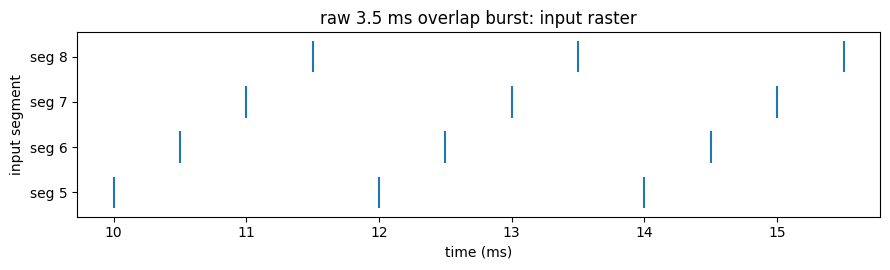

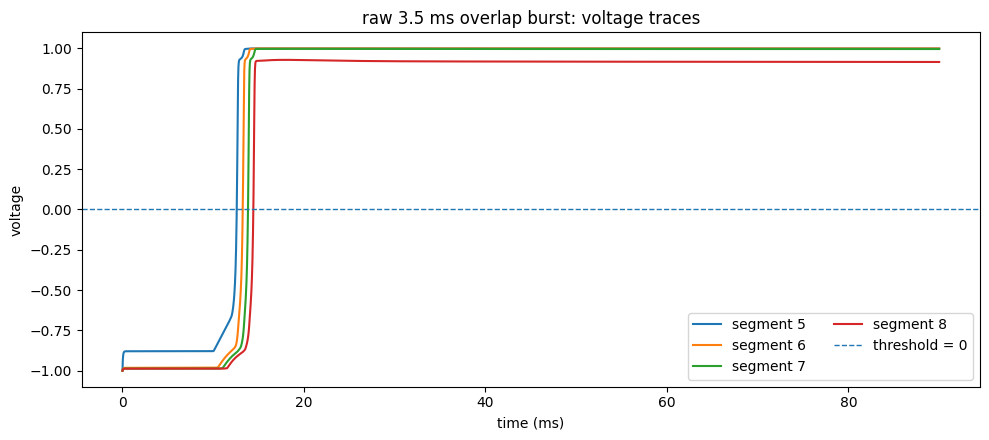

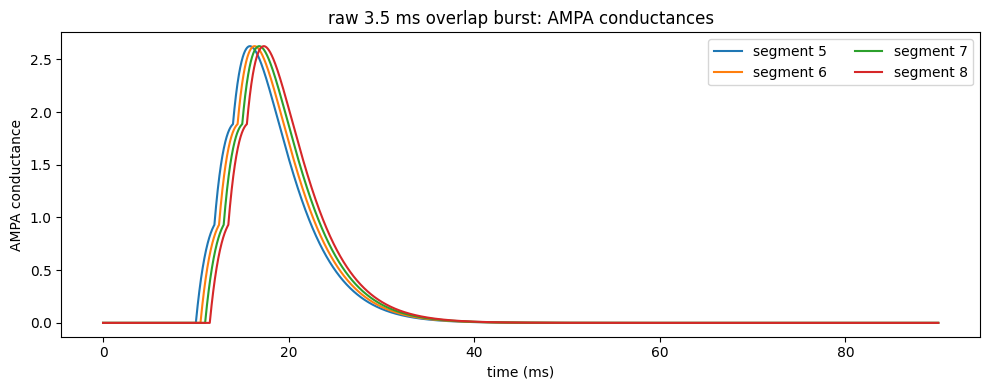

regular success: True
sequence success: False
ordered: True
separated: False
final voltage: 0.915
activation times: {5: 12.6, 6: 13.26, 7: 13.84, 8: 14.44}
step separations: [0.66 0.58 0.6 ]
first-spike filtered


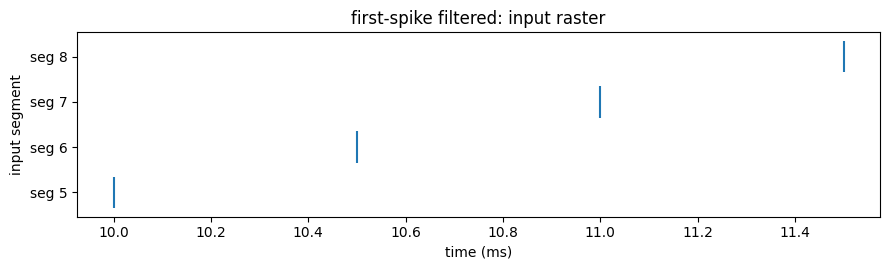

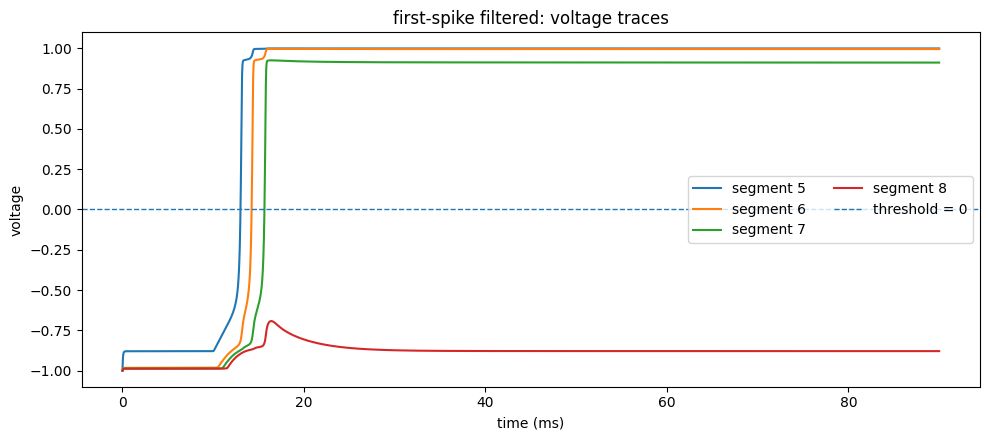

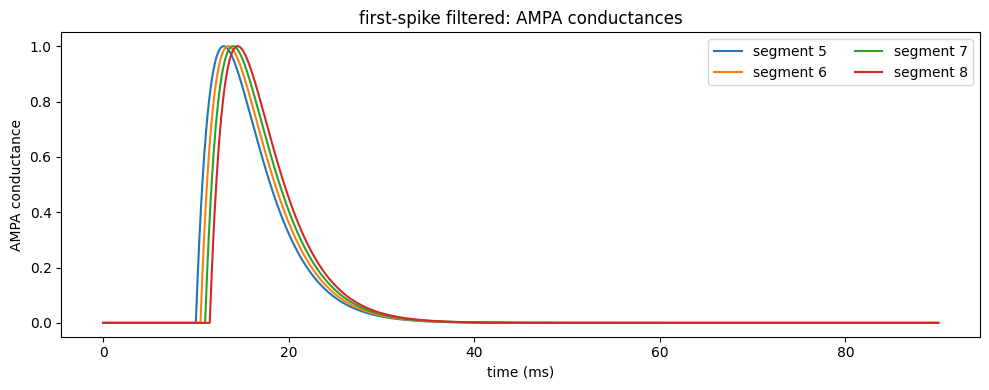

regular success: False
sequence success: False
ordered: False
separated: False
final voltage: -0.879
activation times: {5: 13.02, 6: 14.24, 7: 15.66, 8: nan}
step separations: []


In [10]:
times_raw, V_raw, score_raw = run_case(
    "raw 3.5 ms overlap burst",
    failure_events,
)

times_filtered, V_filtered, score_filtered = run_case(
    "first-spike filtered",
    filtered_events,
)

what if we use it to detect spikes

In [11]:
test_overlaps = np.arange(0.0, 5.0, 0.25)

raw_sequence_successes = []
filtered_sequence_successes = []
raw_min_separations = []
filtered_min_separations = []

for target_overlap_ms in test_overlaps:
    burst_span_ms = (burst_len - 1) * isi_ms
    onset_step_ms = burst_span_ms - target_overlap_ms

    events, raster = make_burst_sequence(
        sequence_segments=sequence_segments,
        start_time=start_time,
        onset_step_ms=onset_step_ms,
        burst_len=burst_len,
        isi_ms=isi_ms,
        weight=weight,
    )

    filtered_events = first_spike_filter(events)

    times_raw_sweep, V_raw_sweep = simulate_dendrite(
        n_segments=n_segments,
        T=T,
        dt=dt,
        G_NMDA=G_NMDA,
        G_KIR=G_KIR,
        G_ax=G_ax,
        ampa_events=events,
    )

    raw_score = score_sequence_order(
        times_raw_sweep,
        V_raw_sweep,
        sequence_segments=sequence_segments,
        threshold=0.0,
        min_step_separation_ms=1.0,
    )

    times_filt_sweep, V_filt_sweep = simulate_dendrite(
        n_segments=n_segments,
        T=T,
        dt=dt,
        G_NMDA=G_NMDA,
        G_KIR=G_KIR,
        G_ax=G_ax,
        ampa_events=filtered_events,
    )

    filtered_score = score_sequence_order(
        times_filt_sweep,
        V_filt_sweep,
        sequence_segments=sequence_segments,
        threshold=0.0,
        min_step_separation_ms=1.0,
    )

    raw_min_sep = (
        float(np.min(raw_score["step_separations"]))
        if len(raw_score["step_separations"]) > 0
        else np.nan
    )

    filtered_min_sep = (
        float(np.min(filtered_score["step_separations"]))
        if len(filtered_score["step_separations"]) > 0
        else np.nan
    )

    raw_sequence_successes.append(raw_score["sequence_success"])
    filtered_sequence_successes.append(filtered_score["sequence_success"])
    raw_min_separations.append(raw_min_sep)
    filtered_min_separations.append(filtered_min_sep)

    print("=" * 60)
    print("target overlap:", round(float(target_overlap_ms), 2), "ms")
    print("onset step:", round(float(onset_step_ms), 2), "ms")
    print("raw sequence success:", raw_score["sequence_success"])
    print("filtered sequence success:", filtered_score["sequence_success"])
    print("raw step separations:", np.round(raw_score["step_separations"], 3))
    print("filtered step separations:", np.round(filtered_score["step_separations"], 3))

target overlap: 0.0 ms
onset step: 4.0 ms
raw sequence success: True
filtered sequence success: True
raw step separations: [4. 4. 4.]
filtered step separations: [3.96 4.   4.  ]
target overlap: 0.25 ms
onset step: 3.75 ms
raw sequence success: True
filtered sequence success: True
raw step separations: [3.74 3.76 3.74]
filtered step separations: [3.7  3.76 3.74]
target overlap: 0.5 ms
onset step: 3.5 ms
raw sequence success: True
filtered sequence success: True
raw step separations: [3.5 3.5 3.5]
filtered step separations: [3.46 3.5  3.5 ]
target overlap: 0.75 ms
onset step: 3.25 ms
raw sequence success: True
filtered sequence success: True
raw step separations: [3.24 3.26 3.24]
filtered step separations: [3.2  3.26 3.24]
target overlap: 1.0 ms
onset step: 3.0 ms
raw sequence success: True
filtered sequence success: True
raw step separations: [3. 3. 3.]
filtered step separations: [2.94 3.   3.02]
target overlap: 1.25 ms
onset step: 2.75 ms
raw sequence success: True
filtered sequence su

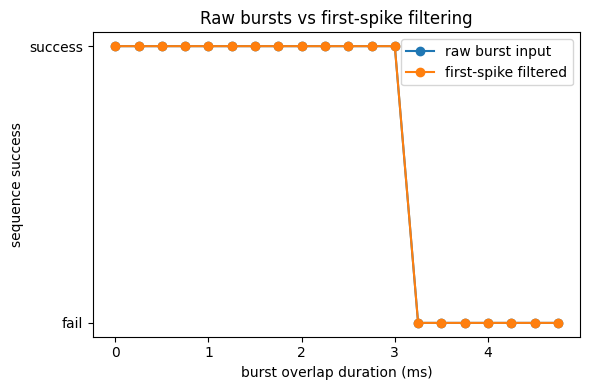

In [12]:
plt.figure(figsize=(6, 4))

plt.plot(
    test_overlaps,
    raw_sequence_successes,
    marker="o",
    label="raw burst input",
)

plt.plot(
    test_overlaps,
    filtered_sequence_successes,
    marker="o",
    label="first-spike filtered",
)

plt.xlabel("burst overlap duration (ms)")
plt.ylabel("sequence success")
plt.yticks([0, 1], ["fail", "success"])
plt.title("Raw bursts vs first-spike filtering")
plt.legend()
plt.tight_layout()
plt.show()

adding refractory period

In [13]:
def refractory_filter(events, refractory_ms=2.5):
    kept_events = []

    events_by_seg = {}
    for event in events:
        seg = int(event["segment"])
        events_by_seg.setdefault(seg, []).append(event)

    for seg, seg_events in events_by_seg.items():
        seg_events = sorted(seg_events, key=lambda e: e["time"])

        last_kept_time = -np.inf

        for event in seg_events:
            event_time = float(event["time"])

            if event_time - last_kept_time >= refractory_ms:
                kept_events.append(event)
                last_kept_time = event_time

    kept_events = sorted(kept_events, key=lambda e: e["time"])

    return kept_events

In [14]:
times_refrac, V_refrac, score_refrac = run_case(
    f"refractory filtered input, {refractory_ms} ms",
    refractory_events,
)

NameError: name 'refractory_ms' is not defined